This is task 3 of Pandahat Adverserial Learning Path. This tasks focuses on Convolutional Neural Networks. What are Convolution Neural Networks? A Convolutional Neural Network (CNN) is a type of deep learning model that's used for spatially structured data (Basically grid like data). It's main use case is computer vision, this being image classification, object detection, semantic segmentation and facial recognition. In this case, the CNN is being used for satellite NDVI images. The results from the CNN's training will be compared to the Support Vector machine (SVM) from task 2, additionally it'll also be compared the pre-trained model DeepLabV3+. How does the CNN work, unlike a regular Nueral Network (NN) that is FC based, meaning it connects every neuron to every input. This becomes cumbersome as the amount of input increases, it also ignores spatial structure, and treats closed pixel as unrelated even their part of the same object (trees, bushes, clouds, bare soil, etc.). A CNN on the other hand, slides a small filter across the image (The best way to think about it is a magnifying glass), this filter is a 3x3 grid meaning it only requires 9 weights, it looks at one small patch of pixels, does a dot product, moves one step and repeats.

# Convolutional Neural Network

Imports:

In [1]:
import numpy as np
import os
import glob
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import confusion_matrix
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import seaborn as sns


class mapping/id mapping:

In [2]:
class_to_id = {
    "Water/Cloud":        0,
    "Bare Soil":          1,
    "Sparse Vegetation":  2,
    "Dense Vegetation":   3
}

Sample loader:

In [3]:
base_dir = os.path.join(os.getcwd(), "..")
labels_path = os.path.join(base_dir, "labels")
samples_path = os.path.join(base_dir, "samples")

sample_files = sorted(glob.glob(os.path.join(samples_path, "*.tiff")))
label_files = sorted(glob.glob(os.path.join(labels_path,  "*.tiff")))
print(f"Found {len(sample_files)} samples, {len(label_files)} labels")

Found 614 samples, 614 labels


Extracting patches and assigning classes:

In [5]:
PATCH_SIZE = 7
HALF = PATCH_SIZE // 2  
PATCHES_PER_IMAGE = 50   

patches = []  
for img_path, lbl_path in zip(sample_files, label_files):
    img = np.array(Image.open(img_path))   
    label = np.array(Image.open(lbl_path))    

    ndvi = (label / 255.0) * 2 - 1
    H, W = img.shape[:2]

    rows = np.random.randint(HALF, H - HALF, size=PATCHES_PER_IMAGE)
    cols = np.random.randint(HALF, W - HALF, size=PATCHES_PER_IMAGE)

    for r, c in zip(rows, cols):
        patch = img[r-HALF:r+HALF+1, c-HALF:c+HALF+1, :]  

        ndvi_val = ndvi[r, c]
        
        if ndvi_val < 0:   
            veg_class = "Water/Cloud"
        elif ndvi_val < 0.2: 
            veg_class = "Bare Soil"
        elif ndvi_val < 0.5: 
            veg_class = "Sparse Vegetation"
        else:                
            veg_class = "Dense Vegetation"

        patches.append((patch, class_to_id[veg_class]))

print(f"Total patches collected: {len(patches)}")

Total patches collected: 30700


PyTorch Dataset and test split:

In [6]:
class PatchDataset(Dataset):
    def __init__(self, patches):
        self.patches = patches

    def __len__(self):
        return len(self.patches)

    def __getitem__(self, idx):
        patch, label = self.patches[idx]
        x = torch.tensor(patch / 255.0, dtype=torch.float32).permute(2, 0, 1)
        y = torch.tensor(label, dtype=torch.long)
        return x, y


train_patches, test_patches = train_test_split(
    patches, test_size=0.2, random_state=42
)

train_dataset = PatchDataset(train_patches)
test_dataset = PatchDataset(test_patches)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset,  batch_size=64, shuffle=False)

print(f"Train: {len(train_dataset)} | Test: {len(test_dataset)}")


Train: 24560 | Test: 6140


CNN Model:

In [7]:
class VegetationCNN(nn.Module):
    def __init__(self, num_classes=4):
        super(VegetationCNN, self).__init__()

        def conv_block(in_ch, out_ch, k):
            return nn.Sequential(
                nn.Conv2d(in_ch, out_ch, kernel_size=k, padding=0),
                nn.ReLU(),
                nn.Dropout2d(p=0.1)
            )

        self.conv1 = conv_block(3,  20, 3)
        self.conv2 = conv_block(20, 20, 3)
        self.conv3 = conv_block(20, 20, 3)
        self.conv4 = nn.Sequential(
            nn.Conv2d(20, 100, kernel_size=1),
            nn.ReLU(),
            nn.Dropout2d(p=0.1)
        )

        self.fc = nn.Linear(100, num_classes)

    def forward(self, x):
        x = self.conv1(x)   
        x = self.conv2(x)  
        x = self.conv3(x)   
        x = self.conv4(x)   
        x = x.view(x.size(0), -1)  
        x = self.fc(x)      
        return x

Training and validation (This takes some time):

In [8]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\nUsing device: {device}")

model = VegetationCNN(num_classes=4).to(device)
criterion = nn.CrossEntropyLoss(weight=torch.tensor(
    [3.0, 1.5, 1.0, 1.0], dtype=torch.float32).to(device))
optimizer = optim.Adam(model.parameters(), lr=0.001)

train_losses = []
val_losses = []

EPOCHS = 20

for epoch in range(EPOCHS):
    model.train()
    total_loss, correct, total = 0, 0, 0

    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        preds = outputs.argmax(dim=1)
        correct += (preds == y_batch).sum().item()
        total += y_batch.size(0)

    train_acc = correct / total
    avg_train_loss = total_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    model.eval()
    val_loss = 0
    val_correct = 0
    val_total = 0
    
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            val_loss += loss.item()
            preds = outputs.argmax(dim=1)
            val_correct += (preds == y_batch).sum().item()
            val_total += y_batch.size(0)
    
    avg_val_loss = val_loss / len(test_loader)
    val_acc = val_correct / val_total
    val_losses.append(avg_val_loss)

    print(f"Epoch {epoch+1:02d}/{EPOCHS} | Train Loss: {avg_train_loss:.4f} | Train Acc: {train_acc:.4f} | Val Loss: {avg_val_loss:.4f} | Val Acc: {val_acc:.4f}")



Using device: cpu
Epoch 01/20 | Train Loss: 1.1285 | Train Acc: 0.4765 | Val Loss: 1.0228 | Val Acc: 0.5270
Epoch 02/20 | Train Loss: 0.9514 | Train Acc: 0.6021 | Val Loss: 0.7711 | Val Acc: 0.7391
Epoch 03/20 | Train Loss: 0.7953 | Train Acc: 0.7114 | Val Loss: 0.6873 | Val Acc: 0.7598
Epoch 04/20 | Train Loss: 0.7462 | Train Acc: 0.7289 | Val Loss: 0.6757 | Val Acc: 0.7192
Epoch 05/20 | Train Loss: 0.7108 | Train Acc: 0.7343 | Val Loss: 0.5955 | Val Acc: 0.7979
Epoch 06/20 | Train Loss: 0.6872 | Train Acc: 0.7491 | Val Loss: 0.6345 | Val Acc: 0.7707
Epoch 07/20 | Train Loss: 0.6743 | Train Acc: 0.7514 | Val Loss: 0.5859 | Val Acc: 0.7987
Epoch 08/20 | Train Loss: 0.6645 | Train Acc: 0.7555 | Val Loss: 0.6192 | Val Acc: 0.7840
Epoch 09/20 | Train Loss: 0.6587 | Train Acc: 0.7590 | Val Loss: 0.5762 | Val Acc: 0.7992
Epoch 10/20 | Train Loss: 0.6516 | Train Acc: 0.7658 | Val Loss: 0.5643 | Val Acc: 0.8052
Epoch 11/20 | Train Loss: 0.6421 | Train Acc: 0.7687 | Val Loss: 0.5468 | Val Acc

Evaluation:

In [9]:
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        outputs = model(X_batch)
        preds = outputs.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(y_batch.numpy())

accuracy = accuracy_score(all_labels, all_preds)
print(f"\nTest Accuracy: {accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(
    all_labels, all_preds,
    target_names=['Water/Cloud', 'Bare Soil', 'Sparse Veg', 'Dense Veg']
))



Test Accuracy: 0.8174

Classification Report:
              precision    recall  f1-score   support

 Water/Cloud       0.61      0.47      0.53       323
   Bare Soil       0.76      0.73      0.75      1176
  Sparse Veg       0.79      0.86      0.83      2453
   Dense Veg       0.90      0.86      0.88      2188

    accuracy                           0.82      6140
   macro avg       0.77      0.73      0.75      6140
weighted avg       0.82      0.82      0.82      6140



Confusion Matrix Visualization:

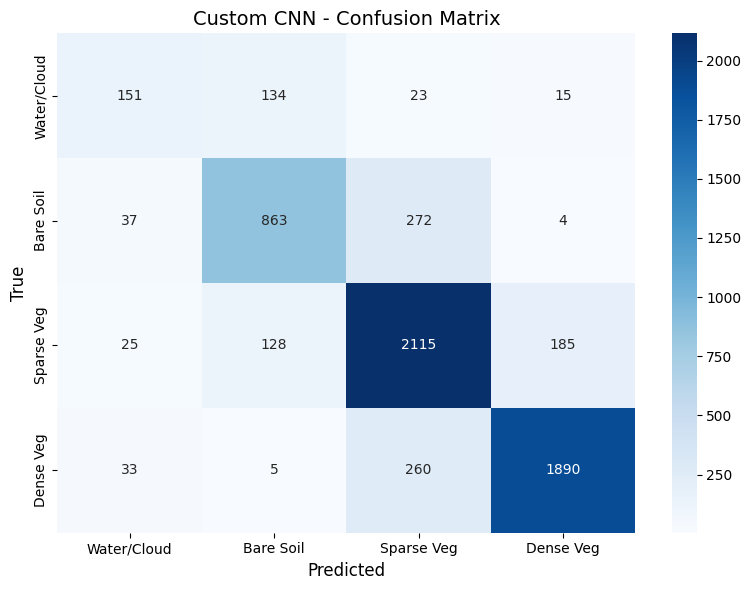


Confusion Matrix (raw values):
[[ 151  134   23   15]
 [  37  863  272    4]
 [  25  128 2115  185]
 [  33    5  260 1890]]

 Confusion matrix saved to: cnn_confusion_matrix.png


In [10]:
class_names = ['Water/Cloud', 'Bare Soil', 'Sparse Veg', 'Dense Veg']

cm = confusion_matrix(all_labels, all_preds)

# Plot heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('True', fontsize=12)
plt.title('Custom CNN - Confusion Matrix', fontsize=14)
plt.tight_layout()
plt.savefig('cnn_confusion_matrix.png', dpi=150)
plt.show()

print("\nConfusion Matrix (raw values):")
print(cm)
print(f"\n Confusion matrix saved to: cnn_confusion_matrix.png")

Loss Curves Visualization:

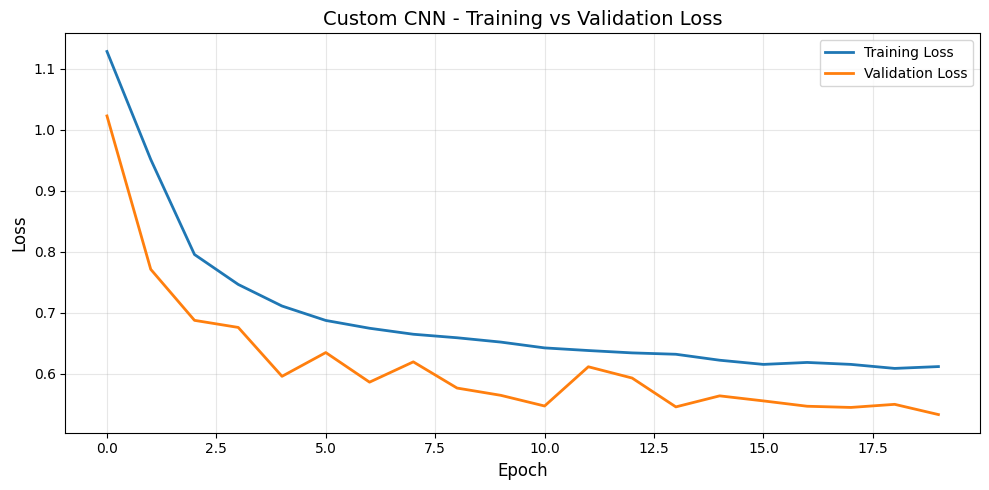

Length of train_losses: 20
Length of val_losses: 20
First 5 train losses: [1.1285210042260587, 0.951350380666554, 0.7953477168921381, 0.7462187736139944, 0.7108118049800396]
Last 5 train losses: [0.6150315647634367, 0.6182441259734333, 0.6150454782570401, 0.6084471787326038, 0.6114554943051189]
First 5 val losses: [1.0227565293510754, 0.7710866245130698, 0.6873228782787919, 0.6756944727773467, 0.595466620909671]
Last 5 val losses: [0.5551308070619901, 0.5463609723374248, 0.5444054324179888, 0.5494910742466649, 0.5327037752916416]
Final Training Loss: 0.6115
Final Validation Loss: 0.5327

Training behavior looks good - losses are balanced

Loss curves saved to: cnn_loss_curves.png


In [13]:
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Training Loss', linewidth=2)
plt.plot(val_losses, label='Validation Loss', linewidth=2)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.title('Custom CNN - Training vs Validation Loss', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('cnn_loss_curves.png', dpi=150)
plt.show()

print(f"Length of train_losses: {len(train_losses)}")
print(f"Length of val_losses: {len(val_losses)}")
print(f"First 5 train losses: {train_losses[:5]}")
print(f"Last 5 train losses: {train_losses[-5:]}")
print(f"First 5 val losses: {val_losses[:5]}")
print(f"Last 5 val losses: {val_losses[-5:]}")
print(f"Final Training Loss: {train_losses[-1]:.4f}")
print(f"Final Validation Loss: {val_losses[-1]:.4f}")

# Check for overfitting/underfitting
if val_losses[-1] > train_losses[-1] * 1.2:
    print("\n Warning: Possible overfitting (validation loss > training loss by 20%)")
    print("   Consider: more regularization, dropout, or early stopping")
elif val_losses[-1] < train_losses[-1] * 0.8:
    print("\nWarning: Possible underfitting (validation loss < training loss)")
    print("   Consider: more epochs or a more complex model")
else:
    print("\nTraining behavior looks good - losses are balanced")

print(f"\nLoss curves saved to: cnn_loss_curves.png")

Prediction Visualizations:

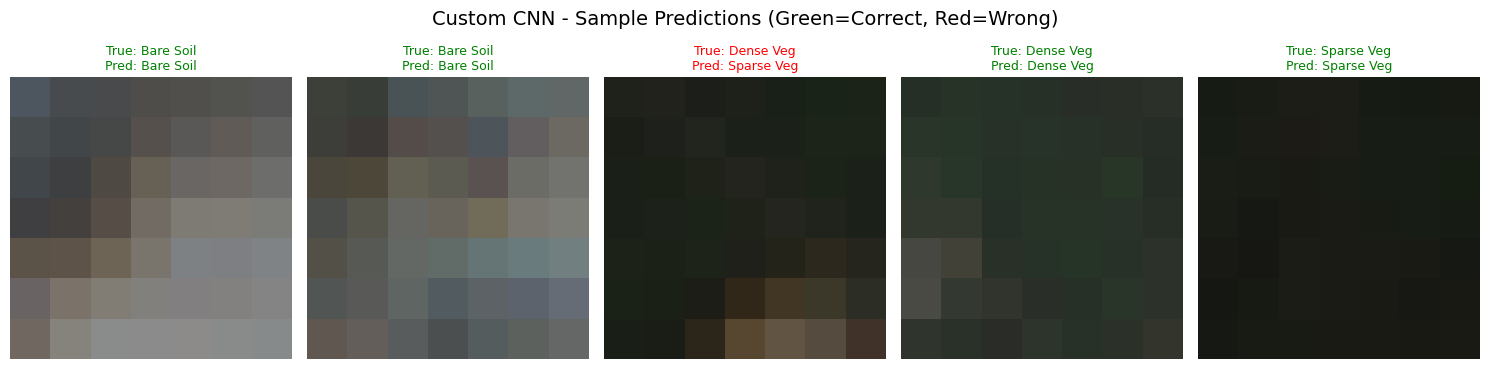


Prediction Details:
Sample 1: True=Bare Soil, Pred=Bare Soil [ CORRECT]
Sample 2: True=Bare Soil, Pred=Bare Soil [ CORRECT]
Sample 3: True=Dense Veg, Pred=Sparse Veg [ WRONG]
Sample 4: True=Dense Veg, Pred=Dense Veg [ CORRECT]
Sample 5: True=Sparse Veg, Pred=Sparse Veg [ CORRECT]

Accuracy on these 5 samples: 4/5 = 80%

Predictions visualization saved to: cnn_predictions.png


In [12]:
model.eval()
sample_images = []
sample_labels = []
sample_preds = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        outputs = model(X_batch)
        preds = outputs.argmax(dim=1)
        
        for i in range(min(5, len(X_batch))):
            sample_images.append(X_batch[i].cpu())
            sample_labels.append(y_batch[i].item())
            sample_preds.append(preds[i].item())
        
        if len(sample_images) >= 5:
            break

class_names = ['Water/Cloud', 'Bare Soil', 'Sparse Veg', 'Dense Veg']


fig, axes = plt.subplots(1, 5, figsize=(15, 4))

for i, (img, true_label, pred_label) in enumerate(zip(sample_images[:5], sample_labels[:5], sample_preds[:5])):
    img_display = img.permute(1, 2, 0).numpy()
    
    axes[i].imshow(img_display)
    color = 'green' if true_label == pred_label else 'red'
    axes[i].set_title(f'True: {class_names[true_label]}\nPred: {class_names[pred_label]}', 
                      color=color, fontsize=9)
    axes[i].axis('off')

plt.suptitle('Custom CNN - Sample Predictions (Green=Correct, Red=Wrong)', fontsize=14)
plt.tight_layout()
plt.savefig('cnn_predictions.png', dpi=150)
plt.show()

print("\nPrediction Details:")
correct_count = 0
for i, (true_label, pred_label) in enumerate(zip(sample_labels[:5], sample_preds[:5])):
    status = " CORRECT" if true_label == pred_label else " WRONG"
    if true_label == pred_label:
        correct_count += 1
    print(f"Sample {i+1}: True={class_names[true_label]}, Pred={class_names[pred_label]} [{status}]")

print(f"\nAccuracy on these 5 samples: {correct_count}/5 = {correct_count/5*100:.0f}%")
print(f"\nPredictions visualization saved to: cnn_predictions.png")

Comparison to SVM:

In [ ]:
print("\n" + "="*55)
print("MODEL COMPARISON")
print("="*55)
print(f"{'Metric':<20} {'SVM':>10} {'CNN':>10}")
print("-"*55)
svm_scores = {"Water/Cloud":0.45, "Bare Soil":0.61, "Sparse Veg":0.76, "Dense Veg":0.87, "Overall Acc":0.75}
from sklearn.metrics import f1_score
cnn_f1 = f1_score(all_labels, all_preds, average=None)
classes = ['Water/Cloud', 'Bare Soil', 'Sparse Veg', 'Dense Veg']
for i, cls in enumerate(classes):
    print(f"{cls:<20} {svm_scores[cls]:>10.2f} {cnn_f1[i]:>10.2f}")
print(f"{'Overall Acc':<20} {0.75:>10.2f} {accuracy:>10.2f}")
print("="*55)

# DeepLabV3+

Imports:

In [11]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision.models.segmentation import deeplabv3_resnet50
from PIL import Image
import numpy as np
import os
import glob
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

class_to_id = {
    "Water/Cloud": 0,
    "Bare Soil": 1,
    "Sparse Vegetation": 2,
    "Dense Vegetation": 3
}

NUM_CLASSES = 4
IMG_SIZE = 256

Load file paths:

In [12]:
base_dir = os.path.join(os.getcwd(), "..")
labels_path = os.path.join(base_dir, "labels")
samples_path = os.path.join(base_dir, "samples")

sample_files = sorted(glob.glob(os.path.join(samples_path, "*.tiff")))
label_files = sorted(glob.glob(os.path.join(labels_path,  "*.tiff")))
print(f"Found {len(sample_files)} samples, {len(label_files)} labels")


Found 614 samples, 614 labels


Build label maps (Unlike CNNs we use the full image):

In [13]:
def build_label_map(label_array):
    # Convert a grayscale label image into a class ID map using NDVI thresholds.
    ndvi = (label_array / 255.0) * 2 - 1
    label_map = np.zeros(ndvi.shape, dtype=np.int64)
    label_map[ndvi < 0] = 0   
    label_map[(ndvi >= 0) & (ndvi < 0.2)] = 1   
    label_map[(ndvi >= 0.2) & (ndvi < 0.5)] = 2   
    label_map[ndvi >= 0.5] = 3  
    return label_map

Dataset class for full images:

In [14]:
class SegmentationDataset(Dataset):
   
    def __init__(self, img_paths, lbl_paths):
        self.img_paths = img_paths
        self.lbl_paths = lbl_paths

    def __len__(self):
        return len(self.img_paths)

    def __getitem__(self, idx):
        img = np.array(Image.open(self.img_paths[idx]).convert("RGB"))

        x = torch.tensor(img / 255.0, dtype=torch.float32).permute(2, 0, 1)

        label = np.array(Image.open(self.lbl_paths[idx]))
        if label.ndim == 3:
            label = label[:, :, 0]
        y = torch.tensor(build_label_map(label), dtype=torch.long)

        return x, y

Train/test split on file paths (if you have a GPU go higher than 4 on the batch size, if not stick to 4 if you like your machine):

In [15]:
train_imgs, test_imgs, train_lbls, test_lbls = train_test_split(sample_files, label_files, test_size=0.2, random_state=42)

train_dataset = SegmentationDataset(train_imgs, train_lbls)
test_dataset = SegmentationDataset(test_imgs,  test_lbls)

deep_train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)
deep_test_loader = DataLoader(test_dataset,  batch_size=4, shuffle=False)

print(f"Train images: {len(train_dataset)} | Test images: {len(test_dataset)}")

Train images: 491 | Test images: 123


Load and replace the classifier head and check for devices(the model already knows edges, textures, shapes. We only retrain the final layer for the 4 vegetation classes instead of the original 21 PASCAL VOC classes):

In [16]:
if torch.backends.mps.is_available():
    device = torch.device("mps")
    print(f"Using MPS (Apple Silicon GPU) - Fast!")
elif torch.cuda.is_available():
    device = torch.device("cuda")
    print(f"Using CUDA (NVIDIA GPU) - Faster!")
else:
    device = torch.device("cpu")
    print(f"Using CPU - This will be really slow...")

deep_model = deeplabv3_resnet50(weights="DEFAULT")
deep_model.classifier[4] = nn.Conv2d(256, NUM_CLASSES, kernel_size=1)
deep_model.aux_classifier[4] = nn.Conv2d(256, NUM_CLASSES, kernel_size=1)
deep_model = deep_model.to(device)

print(f"Model is running on: {device}")

Using MPS (Apple Silicon GPU) - Fast!
Model is running on: mps


Loss and optimiser:

In [17]:
criterion = nn.CrossEntropyLoss(weight=torch.tensor([3.0, 1.5, 1.0, 1.0], dtype=torch.float32).to(device))

# learning rates lower than CNN because the backbone weights are already trained
optimizer = optim.Adam(deep_model.parameters(), lr=0.0001)

Training (this will take some time, god it's slow, how lower epochs because its pretrained):

In [18]:
EPOCHS = 10 
deep_train_losses = []

for epoch in range(EPOCHS):
    deep_model.train()
    total_loss, correct, total = 0, 0, 0

    for X_batch, y_batch in deep_train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()

        result = deep_model(X_batch)
        
        loss = criterion(result['out'], y_batch)
        loss += 0.4 * criterion(result['aux'], y_batch)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        preds = result['out'].argmax(dim=1)
        correct += (preds == y_batch).sum().item()
        total += y_batch.numel()   

    train_acc = correct / total
    avg_train_loss = total_loss / len(deep_train_loader)
    deep_train_losses.append(avg_train_loss)

    print(f"Epoch {epoch+1:02d}/{EPOCHS} | Train Loss: {avg_train_loss:.4f} | Train Acc: {train_acc:.4f}")

Epoch 01/10 | Train Loss: 1.3722 | Train Acc: 0.5865
Epoch 02/10 | Train Loss: 1.0535 | Train Acc: 0.6920
Epoch 03/10 | Train Loss: 0.9640 | Train Acc: 0.7152
Epoch 04/10 | Train Loss: 0.8925 | Train Acc: 0.7355
Epoch 05/10 | Train Loss: 0.8456 | Train Acc: 0.7481
Epoch 06/10 | Train Loss: 0.8119 | Train Acc: 0.7555
Epoch 07/10 | Train Loss: 0.7817 | Train Acc: 0.7630
Epoch 08/10 | Train Loss: 0.7715 | Train Acc: 0.7664
Epoch 09/10 | Train Loss: 0.7615 | Train Acc: 0.7688
Epoch 10/10 | Train Loss: 0.7560 | Train Acc: 0.7689


Evaluation:

In [19]:
deep_model.eval()
deep_all_preds, deep_all_labels = [], []

with torch.no_grad():
    for X_batch, y_batch in deep_test_loader:  
        X_batch = X_batch.to(device)
        result = deep_model(X_batch)
        preds = result['out'].argmax(dim=1).cpu().numpy()
        deep_all_preds.extend(preds.flatten())
        deep_all_labels.extend(y_batch.numpy().flatten())

deep_accuracy = accuracy_score(deep_all_labels, deep_all_preds)
print(f"\nDeepLabV3+ Test Accuracy: {deep_accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(deep_all_labels, deep_all_preds, 
      target_names=['Water/Cloud', 'Bare Soil', 'Sparse Veg', 'Dense Veg']))


DeepLabV3+ Test Accuracy: 0.7494

Classification Report:
              precision    recall  f1-score   support

 Water/Cloud       0.66      0.70      0.68    494034
   Bare Soil       0.73      0.66      0.69   1614027
  Sparse Veg       0.73      0.75      0.74   3274572
   Dense Veg       0.79      0.81      0.80   2678295

    accuracy                           0.75   8060928
   macro avg       0.73      0.73      0.73   8060928
weighted avg       0.75      0.75      0.75   8060928



Confusion matrix: 

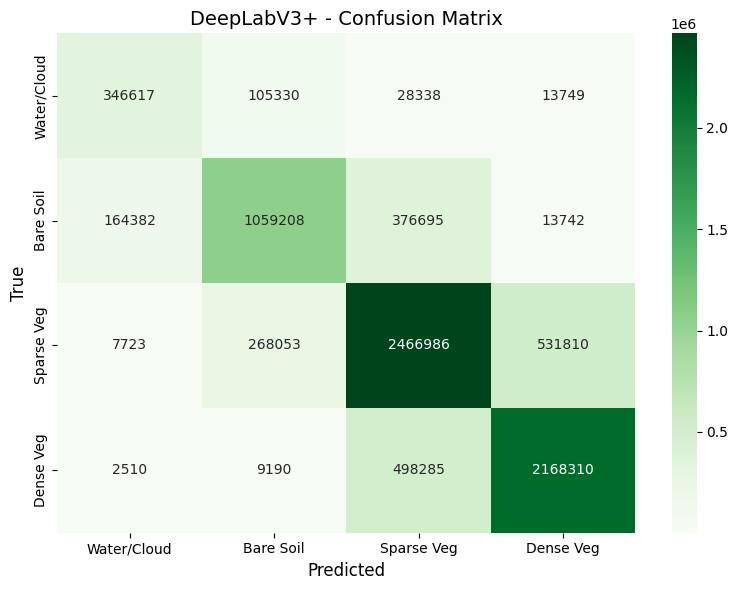

In [20]:
class_names = ['Water/Cloud', 'Bare Soil', 'Sparse Veg', 'Dense Veg']
deep_cm = confusion_matrix(deep_all_labels, deep_all_preds)

plt.figure(figsize=(8, 6))
sns.heatmap(deep_cm, annot=True, fmt='d', cmap='Greens', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('True', fontsize=12)
plt.title('DeepLabV3+ - Confusion Matrix', fontsize=14)
plt.tight_layout()
plt.savefig('deeplabv3_confusion_matrix.png', dpi=150)
plt.show()

Loss curves:

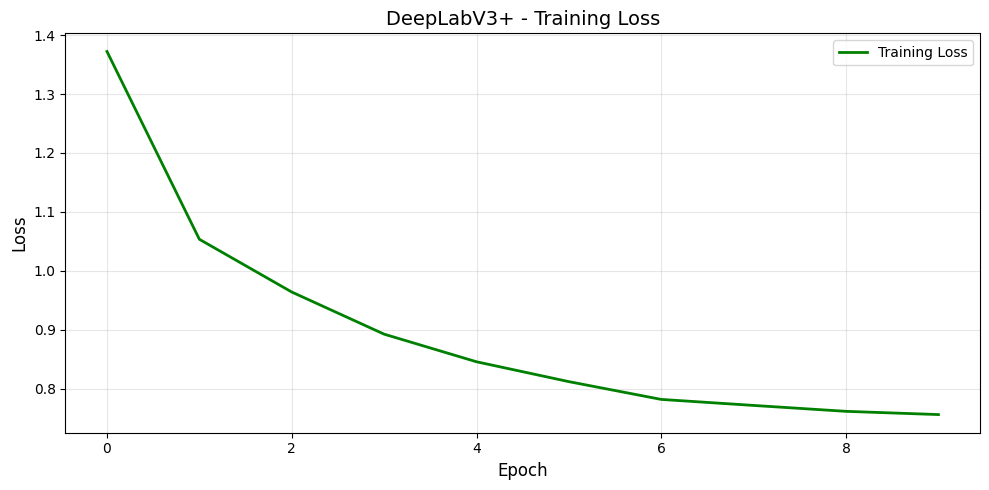

Final Training Loss: 0.7560

 DeepLabV3+ loss curve saved to: deeplabv3_loss_curves.png


In [21]:
plt.figure(figsize=(10, 5))
plt.plot(deep_train_losses, label='Training Loss', linewidth=2, color='green')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.title('DeepLabV3+ - Training Loss', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('deeplabv3_loss_curves.png', dpi=150)
plt.show()

print(f"Final Training Loss: {deep_train_losses[-1]:.4f}")
print(f"\n DeepLabV3+ loss curve saved to: deeplabv3_loss_curves.png")

Visual prediction on one test image:

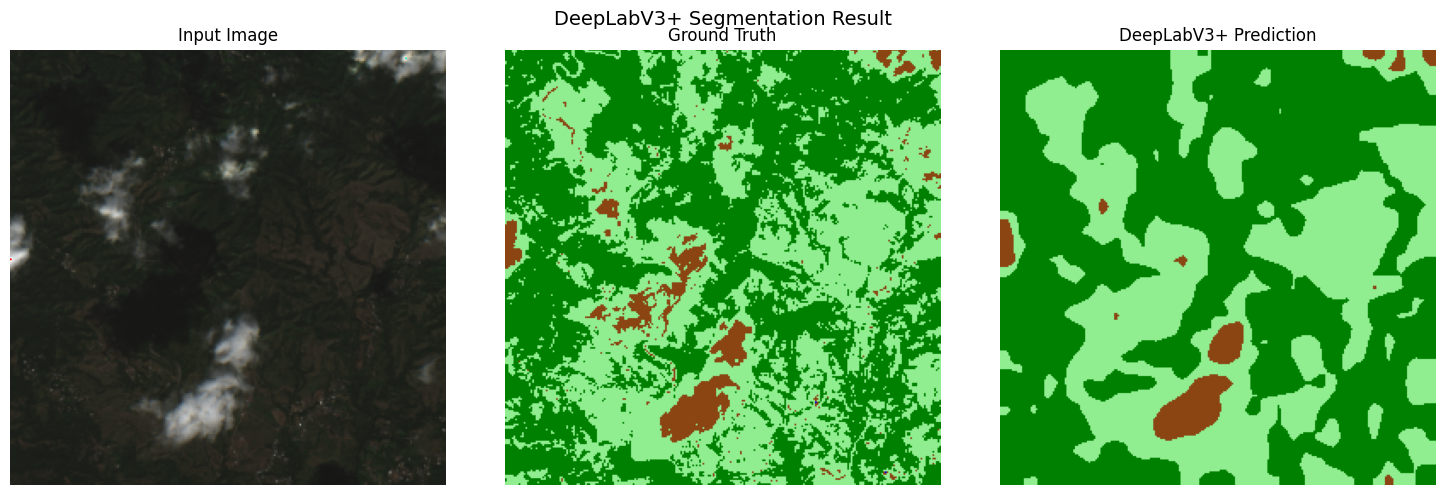

In [22]:
deep_model.eval()  
colours = {
    0: [0,   0,   255],  
    1: [139, 69,  19],   
    2: [144, 238, 144],  
    3: [0,   128, 0],     
}

with torch.no_grad():
    sample_img, sample_lbl = test_dataset[0]
    output = deep_model(sample_img.unsqueeze(0).to(device))  # ✅ FIXED: use deep_model
    pred_map = output['out'].argmax(dim=1).squeeze().cpu().numpy()

def to_colour_map(label_map):
    h, w = label_map.shape
    colour = np.zeros((h, w, 3), dtype=np.uint8)
    for class_id, rgb in colours.items():
        colour[label_map == class_id] = rgb
    return colour

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(sample_img.permute(1, 2, 0).numpy())
axes[0].set_title('Input Image', fontsize=12)
axes[0].axis('off')

axes[1].imshow(to_colour_map(sample_lbl.numpy()))
axes[1].set_title('Ground Truth', fontsize=12)
axes[1].axis('off')

axes[2].imshow(to_colour_map(pred_map))
axes[2].set_title('DeepLabV3+ Prediction', fontsize=12)
axes[2].axis('off')

plt.suptitle('DeepLabV3+ Segmentation Result', fontsize=14)
plt.tight_layout()
plt.savefig('deeplabv3_prediction.png', dpi=150)
plt.show()

# Comparison

In [26]:
from sklearn.metrics import f1_score

deeplab_f1 = f1_score(deep_all_labels, deep_all_preds, average=None)

svm_scores = {
    "Water/Cloud": 0.45,
    "Bare Soil":   0.61,
    "Sparse Veg":  0.76,
    "Dense Veg":   0.87,
    "Overall Acc": 0.75
}

cnn_scores = {
    "Water/Cloud": 0.53,   
    "Bare Soil":   0.75,  
    "Sparse Veg":  0.83,   
    "Dense Veg":   0.88,   
    "Overall Acc": 0.8174  
}

print("\n" + "="*65)
print("FULL MODEL COMPARISON (F1-score per class)")
print("="*65)
print(f"{'Class':<20} {'SVM':>10} {'Custom CNN':>12} {'DeepLabV3+':>12}")
print("-"*65)

classes = ['Water/Cloud', 'Bare Soil', 'Sparse Veg', 'Dense Veg']
for i, cls in enumerate(classes):
    print(f"{cls:<20} {svm_scores[cls]:>10.2f} {cnn_scores[cls]:>12.2f} {deeplab_f1[i]:>12.3f}")

print(f"{'Overall Acc':<20} {svm_scores['Overall Acc']:>10.2f} "
      f"{cnn_scores['Overall Acc']:>12.3f} {deep_accuracy:>12.3f}")
print("="*65)


FULL MODEL COMPARISON (F1-score per class)
Class                       SVM   Custom CNN   DeepLabV3+
-----------------------------------------------------------------
Water/Cloud                0.45         0.53        0.683
Bare Soil                  0.61         0.75        0.693
Sparse Veg                 0.76         0.83        0.743
Dense Veg                  0.87         0.88        0.802
Overall Acc                0.75        0.817        0.749


ANALYSIS:
The custom CNN, suprisingly, was the most accurate model, with an overall accuracy of 81%, outperforming both the SVM baseline (75%) and the pre-trained DeepLabv3+ (74%). The CNN's superior performance can be attributed to its patch-based approach (7×7 patches) which captures local spatial patterns effectively, and its training from scratch on 20 epochs specifically for this dataset. DeepLabV3+, while pre-trained on ImageNet, was limited to 10 epochs due to computational constraints and may benefit from additional fine-tuning. Notably, all models performed best on Dense Vegetation and struggled most with Water/Cloud classification, suggesting this class may benefit from additional training samples or spectral bands.